#  Letshego Ghana — Business Intelligence Deep-Dive

---

## Notebook Structure

| # | Gap | Analysis | Output |
|---|-----|----------|--------|
| 1 | NPL Segmentation Blind Spot | Heat-map by Segment × Channel × Region | PNG + CSV for Power BI |
| 2 | Digital Adoption vs Credit Performance | T-test, point-biserial correlation, logistic regression | Stats table + chart |
| 3 | Complaint-to-Churn Lag Analysis | Cross-correlation, Granger causality test | Lag chart + significance table |
| 4 | Mobile Loan NPL Scorecard | XGBoost classifier, SHAP feature importance | Model metrics + SHAP plot |



> **Data file:** `Letshego_Ghana_BI_Research_Dataset.xlsx`

---

## Setup & Data Load

In [4]:
#Install any missing libraries
import subprocess, sys

required = ['xgboost', 'shap', 'statsmodels', 'openpyxl']
for pkg in required:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

In [1]:
# Core imports
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import pointbiserialr, ttest_ind
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import shap
import os



In [2]:
# Style
LETSHEGO_BLUE   = '#1F4E79'
LETSHEGO_MID    = '#2E75B6'
LETSHEGO_LIGHT  = '#9DC3E6'
LETSHEGO_ACCENT = '#F4B942'   # gold
LETSHEGO_RED    = '#C00000'
LETSHEGO_GREEN  = '#375623'

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
})

In [3]:
# Loading data
XLSX = 'Letshego_Ghana_BI_Research_Dataset.xlsx'

cust   = pd.read_excel(XLSX, sheet_name='Customer_Master')
txn    = pd.read_excel(XLSX, sheet_name='Monthly_Transactions')
kpi    = pd.read_excel(XLSX, sheet_name='Monthly_KPIs')
branch = pd.read_excel(XLSX, sheet_name='Branch_Performance')
comp   = pd.read_excel(XLSX, sheet_name='Customer_Complaints')
prod   = pd.read_excel(XLSX, sheet_name='Product_Performance')

kpi['Month_dt']  = pd.to_datetime(kpi['Month'])
comp['Month_dt'] = pd.to_datetime(comp['Month'])

os.makedirs('outputs', exist_ok=True)

print(' All sheets loaded')
print(f"   Customers : {len(cust):,}")
print(f"   Transactions: {len(txn):,}")
print(f"   KPI months  : {len(kpi)}")
print(f"   Branches    : {branch['Branch'].nunique()} × {kpi['Month'].nunique()} months")
print(f"   Complaint cats: {comp['Category'].nunique()}")
print(f"   Products    : {prod['Product'].nunique()}")

 All sheets loaded
   Customers : 5,000
   Transactions: 40,000
   KPI months  : 45
   Branches    : 10 × 45 months
   Complaint cats: 10
   Products    : 6


---
##  GAP 1 - NPL Segmentation Blind Spot

**Hypothesis:** Letshego reports NPL at portfolio level (~25.6% Sept 2025) but has no public breakdown  
by customer segment, acquisition channel, or region. Different segments likely have dramatically  
different default rates - uniformly pricing risk means subsidising bad segments with good ones.

**Analysis plan:**
1. NPL rate by Segment (bar chart)
2. NPL heat-map: Segment × Acquisition Channel
3. NPL heat-map: Segment × Region
4. Loan-size-adjusted NPL (loss exposure, not just count)
5. Export clean table → Power BI

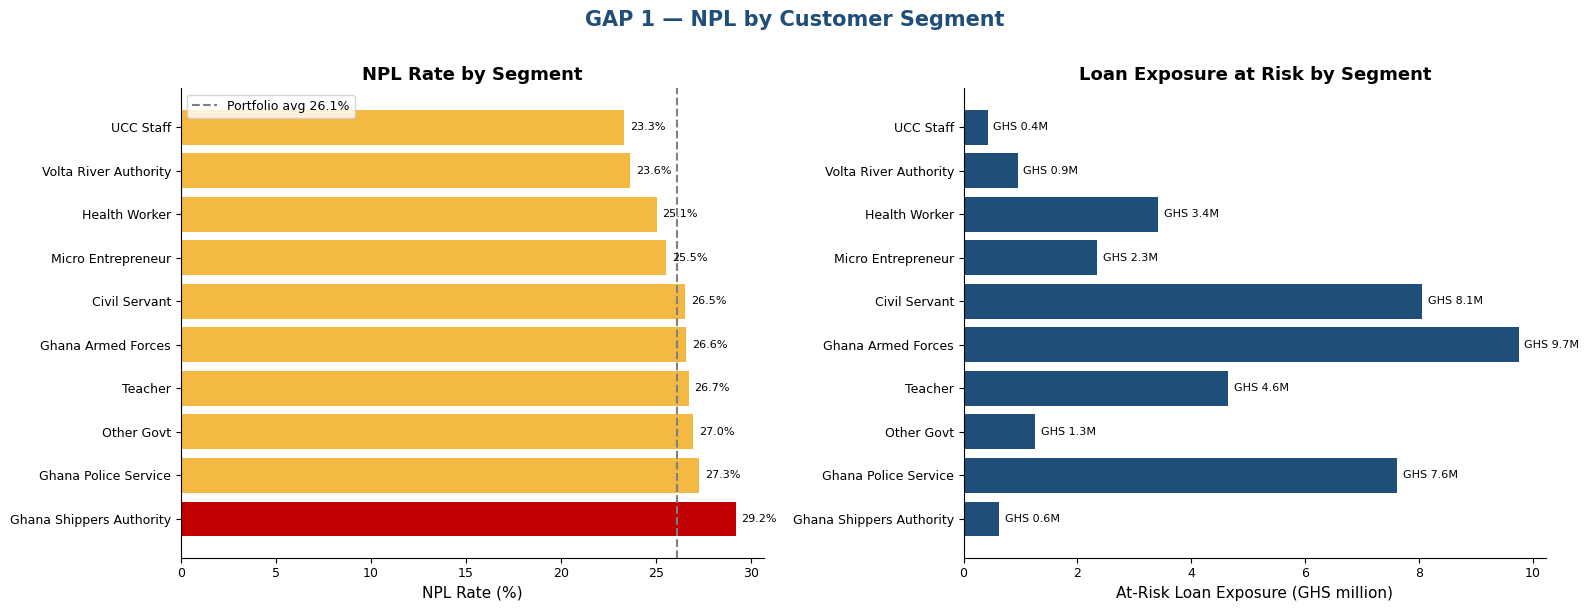

                 Segment  Total  NPL_Rate  At_Risk_GHS
Ghana Shippers Authority    113  0.292035 6.262991e+05
    Ghana Police Service    733  0.272851 7.615607e+06
              Other Govt    256  0.269531 1.259007e+06
                 Teacher    621  0.267311 4.648401e+06
      Ghana Armed Forces    933  0.265809 9.749935e+06
           Civil Servant   1082  0.265250 8.054806e+06
      Micro Entrepreneur    474  0.255274 2.343316e+06
           Health Worker    495  0.250505 3.418642e+06
   Volta River Authority    203  0.236453 9.470897e+05
               UCC Staff     90  0.233333 4.228000e+05


In [ ]:
# 1a. NPL rate by segment
seg_npl = (
    cust.groupby('Segment')
        .agg(Total=('NPL_Flag','count'), Defaulted=('NPL_Flag','sum'),
             Avg_Loan=('Loan_Amount_GHS','mean'))
        .assign(NPL_Rate=lambda d: d.Defaulted/d.Total)
        .sort_values('NPL_Rate', ascending=False)
        .reset_index()
)
seg_npl['At_Risk_GHS'] = seg_npl['Defaulted'] * seg_npl['Avg_Loan']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('GAP 1 — NPL by Customer Segment', fontsize=15,
             fontweight='bold', color=LETSHEGO_BLUE, y=1.01)

# Bar: NPL rate
bars = axes[0].barh(seg_npl['Segment'], seg_npl['NPL_Rate'] * 100,
                    color=[LETSHEGO_RED if r > 0.28 else
                           LETSHEGO_ACCENT if r > 0.22 else
                           LETSHEGO_MID for r in seg_npl['NPL_Rate']])
axes[0].axvline(seg_npl['NPL_Rate'].mean()*100, color='grey',
                linestyle='--', lw=1.5, label=f"Portfolio avg {seg_npl['NPL_Rate'].mean()*100:.1f}%")
axes[0].set_xlabel('NPL Rate (%)')
axes[0].set_title('NPL Rate by Segment', fontweight='bold')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, seg_npl['NPL_Rate']):
    axes[0].text(val*100 + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val*100:.1f}%', va='center', fontsize=8)

# Bar: at-risk GHS
axes[1].barh(seg_npl['Segment'],
             seg_npl['At_Risk_GHS'] / 1e6,
             color=LETSHEGO_BLUE)
axes[1].set_xlabel('At-Risk Loan Exposure (GHS million)')
axes[1].set_title('Loan Exposure at Risk by Segment', fontweight='bold')
for i, (_, row) in enumerate(seg_npl.iterrows()):
    axes[1].text(row['At_Risk_GHS']/1e6 + 0.1, i,
                 f'GHS {row["At_Risk_GHS"]/1e6:.1f}M', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('outputs/gap1_npl_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()
print(seg_npl[['Segment','Total','NPL_Rate','At_Risk_GHS']].to_string(index=False))

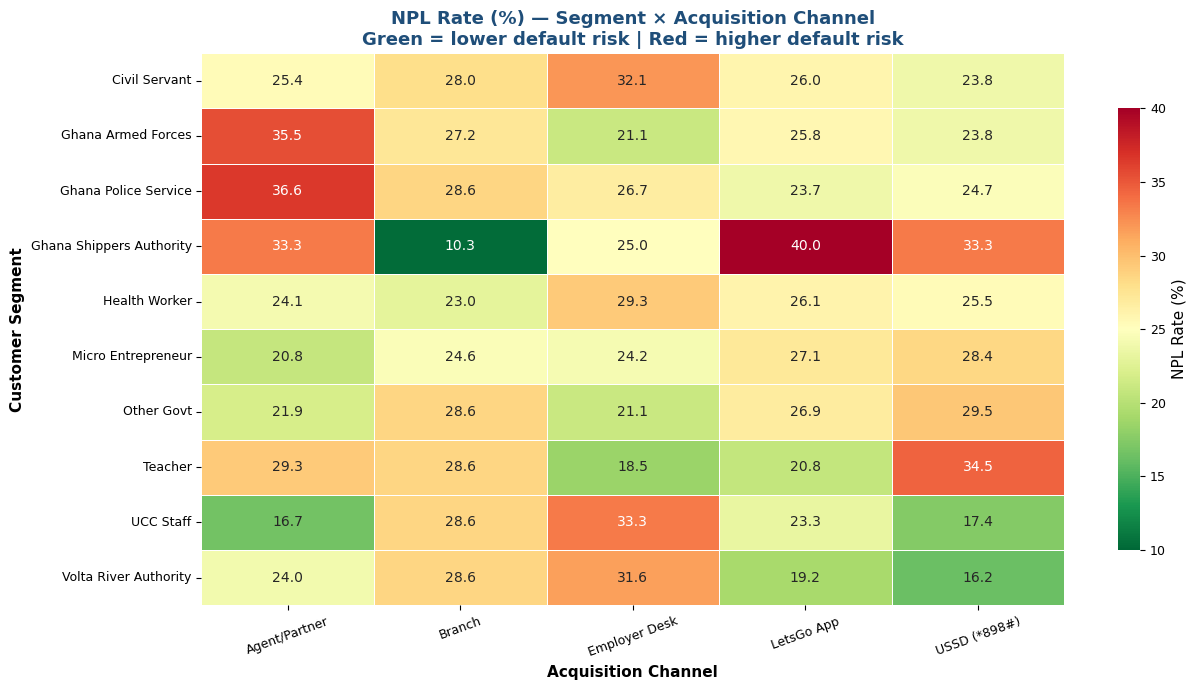


 BI Insight: Cells > 30% are candidates for tightened credit scoring or higher risk pricing.


In [ ]:
# 1b. NPL Heat-map: Segment × Channel
heat_sc = (
    cust.groupby(['Segment','Acquisition_Channel'])['NPL_Flag']
        .mean().unstack() * 100
)

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(
    heat_sc, annot=True, fmt='.1f', cmap='RdYlGn_r',
    linewidths=0.5, linecolor='white',
    vmin=10, vmax=40,
    cbar_kws={'label': 'NPL Rate (%)', 'shrink': 0.8},
    ax=ax
)
ax.set_title('NPL Rate (%) - Segment × Acquisition Channel\n'
             'Green = lower default risk | Red = higher default risk',
             fontweight='bold', fontsize=13, color=LETSHEGO_BLUE)
ax.set_xlabel('Acquisition Channel', fontweight='bold')
ax.set_ylabel('Customer Segment', fontweight='bold')
ax.tick_params(axis='x', rotation=20)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('outputs/gap1_npl_heatmap_segment_channel.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n BI Insight: Cells > 30% are candidates for tightened credit scoring or higher risk pricing.')

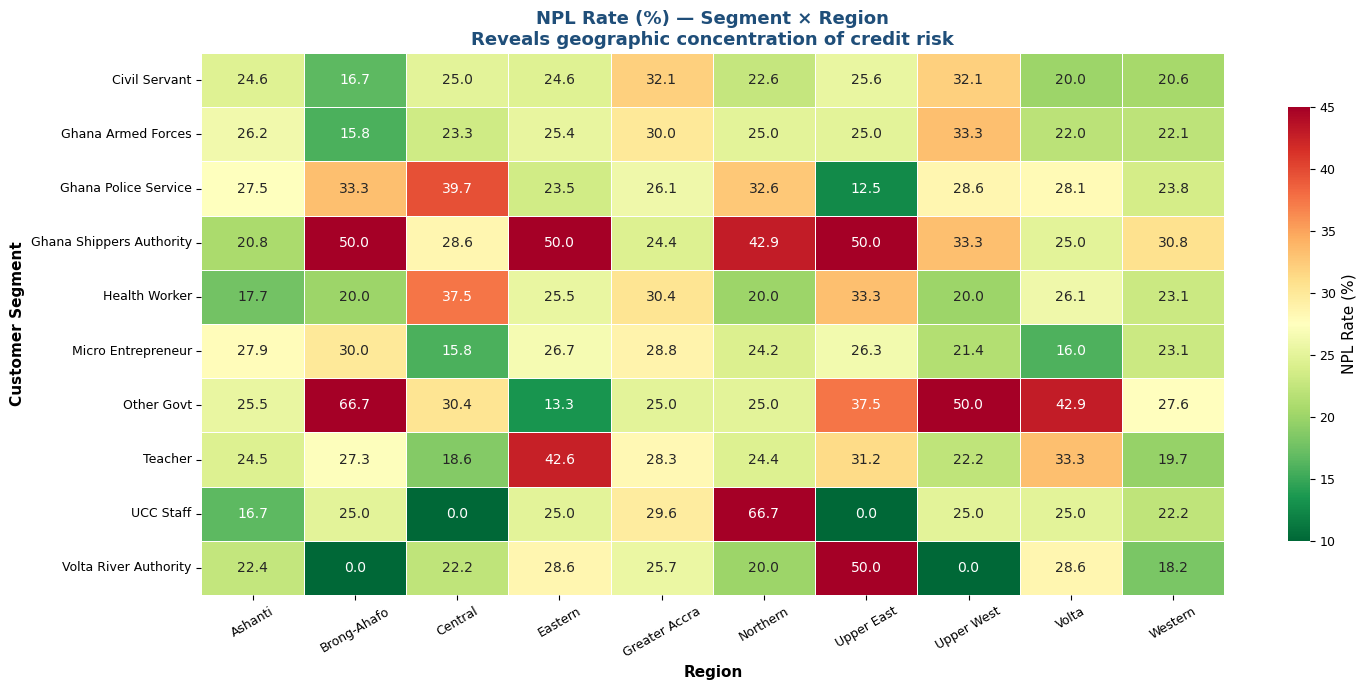

In [6]:
# 1c. NPL Heat-map: Segment × Region
heat_sr = (
    cust.groupby(['Segment','Region'])['NPL_Flag']
        .mean().unstack() * 100
)

fig, ax = plt.subplots(figsize=(15, 7))
sns.heatmap(
    heat_sr, annot=True, fmt='.1f', cmap='RdYlGn_r',
    linewidths=0.5, linecolor='white',
    vmin=10, vmax=45,
    cbar_kws={'label': 'NPL Rate (%)', 'shrink': 0.8},
    ax=ax
)
ax.set_title('NPL Rate (%) — Segment × Region\n'
             'Reveals geographic concentration of credit risk',
             fontweight='bold', fontsize=13, color=LETSHEGO_BLUE)
ax.set_xlabel('Region', fontweight='bold')
ax.set_ylabel('Customer Segment', fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('outputs/gap1_npl_heatmap_segment_region.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Export for Power BI
powerbi_npl = cust.groupby(['Segment','Region','Acquisition_Channel','Primary_Product']).agg(
    Customer_Count=('Customer_ID','count'),
    NPL_Count=('NPL_Flag','sum'),
    NPL_Rate=('NPL_Flag','mean'),
    Avg_Loan_GHS=('Loan_Amount_GHS','mean'),
    Total_At_Risk_GHS=('Loan_Amount_GHS', lambda x: x[cust.loc[x.index,'NPL_Flag']==1].sum())
).reset_index()
powerbi_npl.to_csv('outputs/gap1_npl_powerbi_export.csv', index=False)
print(' Power BI export saved: outputs/gap1_npl_powerbi_export.csv')
print(f'   {len(powerbi_npl):,} rows × {len(powerbi_npl.columns)} columns')

 Power BI export saved: outputs/gap1_npl_powerbi_export.csv
   1,443 rows × 9 columns


---
## GAP 2  Digital Adoption vs Credit Performance

**Hypothesis:** Digitally active customers (App / USSD users) are more engaged,  
more likely to receive timely payment reminders, and therefore have lower NPL rates.  
If proven, Letshego should accelerate digital onboarding as a **credit risk reduction strategy** —  
not just a cost-saving measure.

**Tests:**
- Independent samples t-test: digital vs non-digital NPL rates
- Point-biserial correlation: digital_active ↔ NPL_Flag
- Logistic regression: NPL ~ digital + controls
- Visual: NPL distribution by digital status + acquisition channel

In [8]:
# 2a. T-test & descriptive stats
digital_on  = cust[cust['Digital_Active'] == 1]['NPL_Flag']
digital_off = cust[cust['Digital_Active'] == 0]['NPL_Flag']

t_stat, p_val = ttest_ind(digital_on, digital_off, equal_var=False)
pb_corr, pb_p = pointbiserialr(cust['Digital_Active'], cust['NPL_Flag'])

npl_digital    = digital_on.mean() * 100
npl_nondigital = digital_off.mean() * 100
npl_reduction  = npl_nondigital - npl_digital

print('═' * 60)
print('  GAP 2: DIGITAL ADOPTION vs NPL — STATISTICAL RESULTS')
print('═' * 60)
print(f'  Digital customers    NPL rate: {npl_digital:.2f}%')
print(f'  Non-digital customers NPL rate: {npl_nondigital:.2f}%')
print(f'  Difference (NPL reduction):     {npl_reduction:.2f} pp')
print(f'  T-statistic:                    {t_stat:.4f}')
print(f'  P-value (Welch t-test):         {p_val:.4f}  {" SIGNIFICANT" if p_val < 0.05 else "X not significant"}')
print(f'  Point-biserial correlation:     r = {pb_corr:.4f}, p = {pb_p:.4f}')
print('═' * 60)
print()
if p_val < 0.05:
    print(' FINDING: Digital adoption is a statistically significant')
    print(f'     predictor of lower NPL. Onboarding the {(cust["Digital_Active"]==0).sum():,}')
    print(f'     non-digital customers could reduce portfolio NPL by ~{npl_reduction:.1f} pp.')
    at_risk_saving = (cust[cust['Digital_Active']==0]['Loan_Amount_GHS'].sum() *
                      (npl_nondigital - npl_digital) / 100)
    print(f'     Estimated loan-loss saving: GHS {at_risk_saving:,.0f}')

════════════════════════════════════════════════════════════
  GAP 2: DIGITAL ADOPTION vs NPL — STATISTICAL RESULTS
════════════════════════════════════════════════════════════
  Digital customers    NPL rate: 26.39%
  Non-digital customers NPL rate: 26.27%
  Difference (NPL reduction):     -0.12 pp
  T-statistic:                    0.0913
  P-value (Welch t-test):         0.9273  X not significant
  Point-biserial correlation:     r = 0.0013, p = 0.9273
════════════════════════════════════════════════════════════



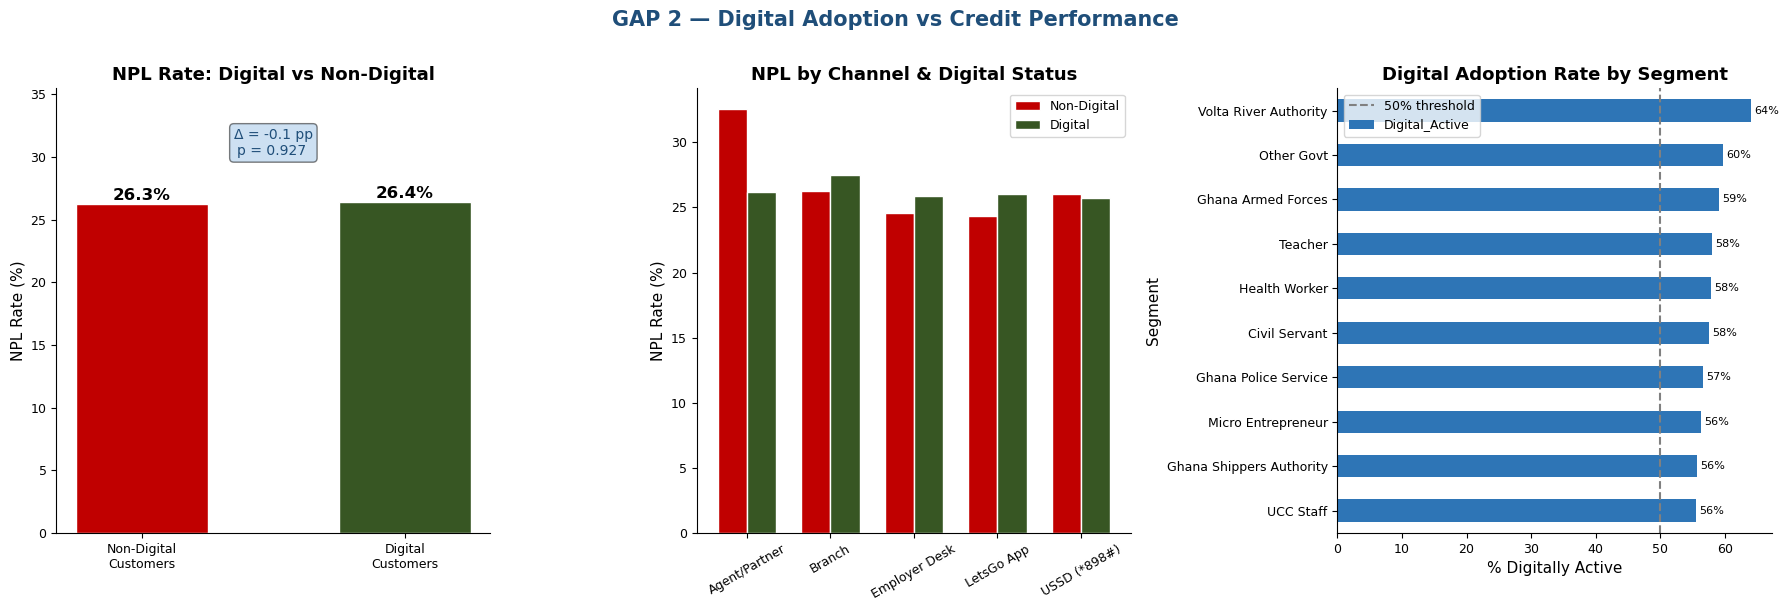

In [9]:
# 2b. Visuals
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('GAP 2 — Digital Adoption vs Credit Performance',
             fontsize=15, fontweight='bold', color=LETSHEGO_BLUE, y=1.01)

# Chart 1: NPL rate bars
bars = axes[0].bar(['Non-Digital\nCustomers', 'Digital\nCustomers'],
                   [npl_nondigital, npl_digital],
                   color=[LETSHEGO_RED, LETSHEGO_GREEN], width=0.5, edgecolor='white')
axes[0].set_ylabel('NPL Rate (%)')
axes[0].set_title('NPL Rate: Digital vs Non-Digital', fontweight='bold')
axes[0].set_ylim(0, npl_nondigital * 1.35)
for bar, val in zip(bars, [npl_nondigital, npl_digital]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].annotate(f'Δ = {npl_reduction:.1f} pp\np = {p_val:.3f} {"★" if p_val<0.05 else ""}',
                 xy=(0.5, 0.85), xycoords='axes fraction', ha='center',
                 fontsize=10, color=LETSHEGO_BLUE,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor=LETSHEGO_LIGHT, alpha=0.5))

# Chart 2: NPL by Channel split by digital
ch_npl = cust.groupby(['Acquisition_Channel','Digital_Active'])['NPL_Flag'].mean().unstack() * 100
ch_npl.columns = ['Non-Digital','Digital']
ch_npl.plot(kind='bar', ax=axes[1], color=[LETSHEGO_RED, LETSHEGO_GREEN],
            edgecolor='white', width=0.7)
axes[1].set_title('NPL by Channel & Digital Status', fontweight='bold')
axes[1].set_ylabel('NPL Rate (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(fontsize=9)

# Chart 3: Digital adoption by segment
seg_digital = cust.groupby('Segment')['Digital_Active'].mean().sort_values() * 100
colors_d = [LETSHEGO_RED if v < 50 else LETSHEGO_MID for v in seg_digital]
seg_digital.plot(kind='barh', ax=axes[2], color=colors_d)
axes[2].axvline(50, color='grey', linestyle='--', lw=1.5, label='50% threshold')
axes[2].set_title('Digital Adoption Rate by Segment', fontweight='bold')
axes[2].set_xlabel('% Digitally Active')
axes[2].legend(fontsize=9)
for i, (seg, val) in enumerate(seg_digital.items()):
    axes[2].text(val + 0.5, i, f'{val:.0f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('outputs/gap2_digital_vs_npl.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# 2c. Logistic regression: NPL ~ digital + controls 
le = LabelEncoder()
model_df = cust[['NPL_Flag','Digital_Active','Age','Monthly_Salary_GHS',
                  'Loan_Amount_GHS','Loan_Term_Months','Interest_Rate',
                  'Gender','Segment','Region','Acquisition_Channel']].copy()

for col in ['Gender','Segment','Region','Acquisition_Channel']:
    model_df[col] = le.fit_transform(model_df[col])

model_df['Loan_to_Salary'] = model_df['Loan_Amount_GHS'] / model_df['Monthly_Salary_GHS'].clip(1)

features = ['Digital_Active','Age','Monthly_Salary_GHS','Loan_to_Salary',
            'Loan_Term_Months','Interest_Rate','Gender','Segment','Region','Acquisition_Channel']
X = model_df[features]
y = model_df['NPL_Flag']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

logit_model = sm.Logit(y, sm.add_constant(X_scaled)).fit(disp=0)

# Format coefficients table
coef_df = pd.DataFrame({
    'Feature': ['const'] + features,
    'Coefficient': logit_model.params.values,
    'Odds_Ratio': np.exp(logit_model.params.values),
    'P_Value': logit_model.pvalues.values
})
coef_df['Significant'] = coef_df['P_Value'].apply(lambda p: 'XXX' if p<0.001 else 'XX' if p<0.01 else 'X' if p<0.05 else '')

print('══ LOGISTIC REGRESSION: NPL ~ Digital + Controls ══')
print(coef_df[coef_df['Feature'] != 'const'].sort_values('P_Value').to_string(index=False))
print(f'\nPseudo-R² (McFadden): {1 - logit_model.llf/logit_model.llnull:.4f}')
print('\nX = p<0.05 XX = p<0.01  XXX = p<0.001')
coef_df.to_csv('outputs/gap2_logit_coefficients.csv', index=False)
print('\n Saved: outputs/gap2_logit_coefficients.csv')

══ LOGISTIC REGRESSION: NPL ~ Digital + Controls ══
            Feature  Coefficient  Odds_Ratio  P_Value Significant
                Age     0.083871    1.087489 0.009276          XX
Acquisition_Channel    -0.048802    0.952370 0.129092            
     Loan_to_Salary    -0.035641    0.964987 0.268165            
             Gender     0.031691    1.032199 0.325665            
      Interest_Rate    -0.033036    0.967504 0.350512            
 Monthly_Salary_GHS     0.024423    1.024724 0.484081            
             Region    -0.009862    0.990187 0.759341            
            Segment    -0.007492    0.992536 0.830625            
     Digital_Active     0.003674    1.003681 0.909099            
   Loan_Term_Months     0.001876    1.001878 0.953511            

Pseudo-R² (McFadden): 0.0023

X = p<0.05 XX = p<0.01  XXX = p<0.001

 Saved: outputs/gap2_logit_coefficients.csv


---
## GAP 3 - Complaint-to-Churn Leading Indicator

**Hypothesis:** Monthly complaint volume - especially unresolved complaints -  
predicts customer churn 1–3 months ahead. If proven, an automated complaint  
spike dashboard becomes a **predictive retention tool**.

**Tests:**
- Time-series visualisation: complaints vs churn overlay
- Cross-correlation function (CCF) at lags 0–6 months
- Granger causality test: do complaints Granger-cause churn?
- OLS regression with optimal lag: Churn(t) ~ Complaints(t-k)

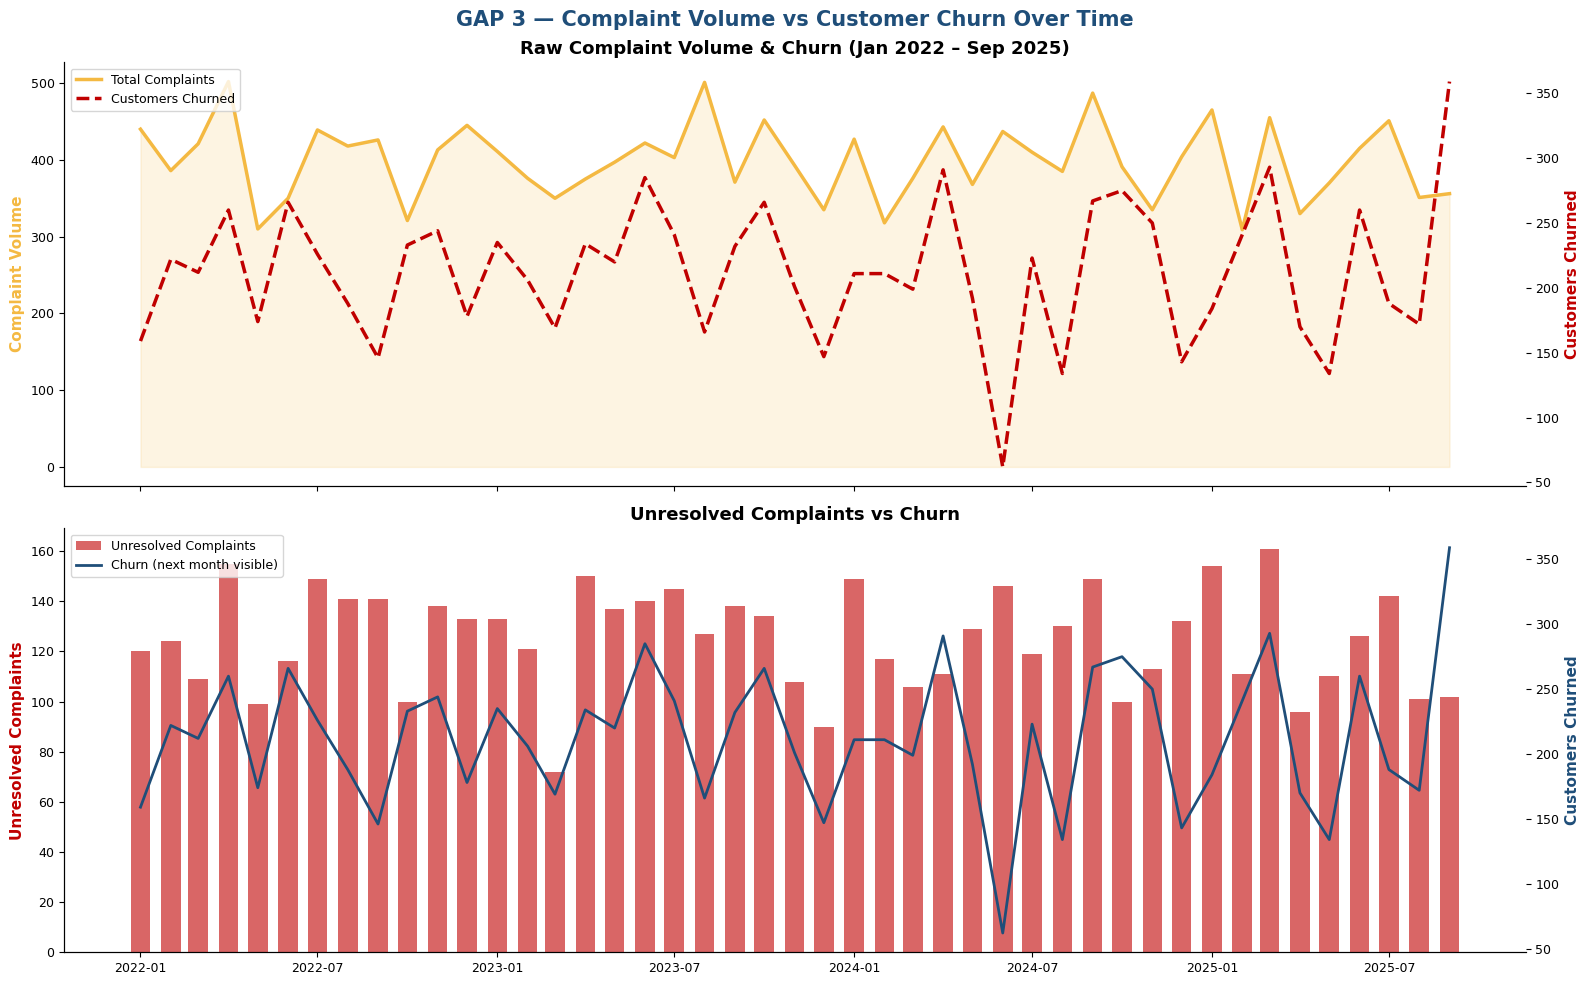

In [11]:
# 3a. Build monthly time series 
monthly_complaints = (
    comp.groupby('Month_dt')
        .agg(Total_Complaints=('Volume','sum'),
             Unresolved=('Pending','sum'),
             Escalated=('Escalated','sum'),
             Avg_Resolution_Days=('Avg_Resolution_Days','mean'))
        .reset_index()
)

ts = kpi[['Month_dt','Customers_Churned','Net_Customer_Growth','Digital_Transactions_Pct']].merge(
    monthly_complaints, on='Month_dt', how='inner'
).sort_values('Month_dt').reset_index(drop=True)

# Normalise for overlay chart
def norm(s):
    return (s - s.min()) / (s.max() - s.min())

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.suptitle('GAP 3 — Complaint Volume vs Customer Churn Over Time',
             fontsize=15, fontweight='bold', color=LETSHEGO_BLUE)

# Panel 1: Raw time series
ax1 = axes[0]
ax2 = ax1.twinx()
ax1.plot(ts['Month_dt'], ts['Total_Complaints'], color=LETSHEGO_ACCENT,
         lw=2.5, label='Total Complaints', zorder=3)
ax1.fill_between(ts['Month_dt'], ts['Total_Complaints'], alpha=0.15, color=LETSHEGO_ACCENT)
ax2.plot(ts['Month_dt'], ts['Customers_Churned'], color=LETSHEGO_RED,
         lw=2.5, linestyle='--', label='Customers Churned')
ax1.set_ylabel('Complaint Volume', color=LETSHEGO_ACCENT, fontweight='bold')
ax2.set_ylabel('Customers Churned', color=LETSHEGO_RED, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
ax1.set_title('Raw Complaint Volume & Churn (Jan 2022 – Sep 2025)', fontweight='bold')

# Panel 2: Unresolved complaints vs churn
ax3 = axes[1]
ax4 = ax3.twinx()
ax3.bar(ts['Month_dt'], ts['Unresolved'], width=20, color=LETSHEGO_RED,
        alpha=0.6, label='Unresolved Complaints')
ax4.plot(ts['Month_dt'], ts['Customers_Churned'], color=LETSHEGO_BLUE,
         lw=2, label='Churn (next month visible)')
ax3.set_ylabel('Unresolved Complaints', color=LETSHEGO_RED, fontweight='bold')
ax4.set_ylabel('Customers Churned', color=LETSHEGO_BLUE, fontweight='bold')
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
ax3.legend(lines3 + lines4, labels3 + labels4, loc='upper left', fontsize=9)
ax3.set_title('Unresolved Complaints vs Churn', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/gap3_complaints_churn_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

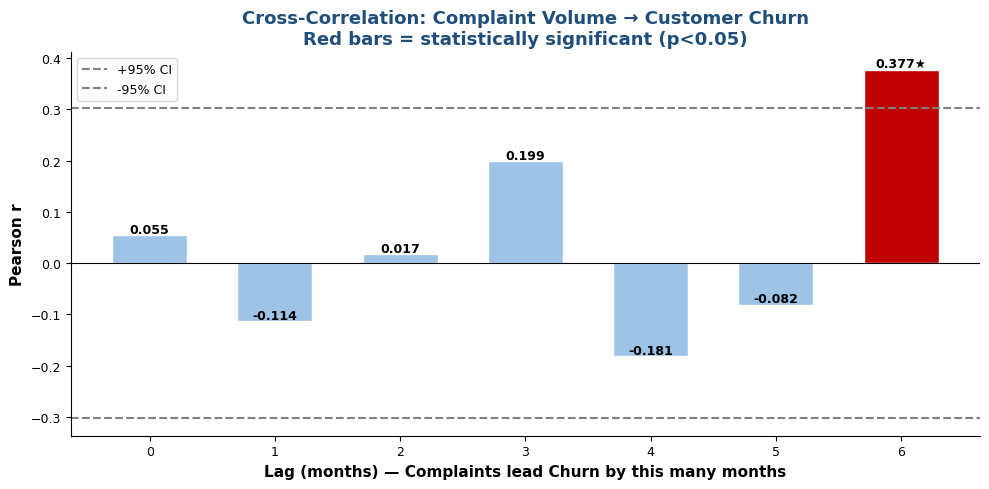


══ CROSS-CORRELATION TABLE ══
 Lag         r        p    CI_95 Significant
   0  0.054611 0.721617 0.292180            
   1 -0.113754 0.462202 0.295481            
   2  0.017150 0.913079 0.298897            
   3  0.198522 0.207551 0.302435            
   4 -0.181374 0.256423 0.306101            
   5 -0.081859 0.615562 0.309903            
   6  0.377425 0.017852 0.313851           ★

 Best predictive lag: 6 month(s)


In [12]:
# 3b. Cross-correlation function (CCF)
max_lag = 6
complaints_s = ts['Total_Complaints']
churn_s      = ts['Customers_Churned']

ccf_vals, ccf_ci = [], []
for lag in range(0, max_lag + 1):
    if lag == 0:
        r, p = stats.pearsonr(complaints_s, churn_s)
    else:
        r, p = stats.pearsonr(complaints_s[:-lag], churn_s[lag:])
    n = len(complaints_s) - lag
    ci = 1.96 / np.sqrt(n)
    ccf_vals.append({'Lag': lag, 'r': r, 'p': p, 'CI_95': ci,
                     'Significant': '★' if p < 0.05 else ''})

ccf_df = pd.DataFrame(ccf_vals)
best_lag = ccf_df.loc[ccf_df['r'].idxmax(), 'Lag']

fig, ax = plt.subplots(figsize=(10, 5))
colors_c = [LETSHEGO_RED if row.p < 0.05 else LETSHEGO_LIGHT for row in ccf_df.itertuples()]
bars = ax.bar(ccf_df['Lag'], ccf_df['r'], color=colors_c, edgecolor='white', width=0.6)
ax.axhline(ccf_df['CI_95'].mean(), color='grey', linestyle='--', lw=1.5, label='+95% CI')
ax.axhline(-ccf_df['CI_95'].mean(), color='grey', linestyle='--', lw=1.5, label='-95% CI')
ax.axhline(0, color='black', lw=0.8)
for bar, row in zip(bars, ccf_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{row.r:.3f}{row.Significant}',
            ha='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Lag (months) — Complaints lead Churn by this many months', fontweight='bold')
ax.set_ylabel('Pearson r', fontweight='bold')
ax.set_title('Cross-Correlation: Complaint Volume → Customer Churn\n'
             'Red bars = statistically significant (p<0.05)',
             fontweight='bold', color=LETSHEGO_BLUE)
ax.set_xticks(range(0, max_lag + 1))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('outputs/gap3_ccf_complaints_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n══ CROSS-CORRELATION TABLE ══')
print(ccf_df.to_string(index=False))
print(f'\n Best predictive lag: {best_lag} month(s)')

In [13]:
# 3c. Granger Causality Test 
print('══ GRANGER CAUSALITY TEST ══')
print('H₀: Complaint volume does NOT Granger-cause customer churn')
print('H₁: Complaint volume DOES Granger-cause customer churn\n')

granger_data = ts[['Customers_Churned','Total_Complaints']].dropna()
granger_results = grangercausalitytests(granger_data, maxlag=4, verbose=False)

for lag, result in granger_results.items():
    f_stat = result[0]['ssr_ftest'][0]
    p_val  = result[0]['ssr_ftest'][1]
    sig    = 'XXX' if p_val<0.001 else 'XX' if p_val<0.01 else 'X' if p_val<0.05 else 'n.s.'
    print(f'  Lag {lag}: F = {f_stat:.4f},  p = {p_val:.4f}  {sig}')

print('\nX p<0.05  XX p<0.01  XXX p<0.001  n.s. = not significant')

# OLS regression with best lag
ts[f'Complaints_lag{best_lag}'] = ts['Total_Complaints'].shift(best_lag)
ts[f'Unresolved_lag{best_lag}'] = ts['Unresolved'].shift(best_lag)
ols_df = ts[['Customers_Churned', f'Complaints_lag{best_lag}', f'Unresolved_lag{best_lag}']].dropna()

X_ols = sm.add_constant(ols_df[[f'Complaints_lag{best_lag}', f'Unresolved_lag{best_lag}']])
ols_model = sm.OLS(ols_df['Customers_Churned'], X_ols).fit()

print(f'\n══ OLS: Churn(t) ~ Complaints(t-{best_lag}) + Unresolved(t-{best_lag}) ══')
print(ols_model.summary().tables[1])
print(f'R² = {ols_model.rsquared:.4f}')

ts.to_csv('outputs/gap3_complaints_churn_timeseries.csv', index=False)
print('\n Saved: outputs/gap3_complaints_churn_timeseries.csv')

══ GRANGER CAUSALITY TEST ══
H₀: Complaint volume does NOT Granger-cause customer churn
H₁: Complaint volume DOES Granger-cause customer churn

  Lag 1: F = 0.4234,  p = 0.5189  n.s.
  Lag 2: F = 0.3255,  p = 0.7242  n.s.
  Lag 3: F = 0.6975,  p = 0.5599  n.s.
  Lag 4: F = 0.5496,  p = 0.7006  n.s.

X p<0.05  XX p<0.01  XXX p<0.001  n.s. = not significant

══ OLS: Churn(t) ~ Complaints(t-6) + Unresolved(t-6) ══
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              34.1871     69.725      0.490      0.627    -107.221     175.596
Complaints_lag6     0.3066      0.220      1.395      0.172      -0.139       0.752
Unresolved_lag6     0.4324      0.553      0.782      0.439      -0.689       1.554
R² = 0.1568

 Saved: outputs/gap3_complaints_churn_timeseries.csv


For the causality test; The model fails to reject H₀ at all lags. Thus, complaint volume does NOT Granger-cause churn(Past complaint volumes do not provide useful predictive information about future churn in your dataset).

Model explains only 15.7% of churn variation(weak explanatory power)

### Critical Business Interpretation
1. Complaints are not predictive of churn: Either customers don’t leave because they complain, or worse… customers leave without complaining.
2. Complaint data is a poor proxy for customer dissatisfaction: This is a major BI gap.
3. Unresolved complaints also don’t predict churn: either resolution tracking is weak, or churn is driven by other hidden factors.

## Proposal to build a Customer Early Warning System
New Predictors will include
* Transaction inactivity
* Loan repayment delays
* Drop in digital usage
* Call center interactions (not just complaints)
* Product holding decline

---
## GAP 4 - Mobile Loan NPL Scorecard (XGBoost)

**Hypothesis:** Mobile Loans carry 2–3× higher NPL than Deduction-at-Source loans.  
As mobile loan share grows toward 50% of the portfolio, total NPL will deteriorate  
unless an **automated credit scorecard** is built into the origination flow.

**Analysis:**
1. Class imbalance check
2. Feature engineering
3. XGBoost classifier with cross-validation
4. Model evaluation: ROC-AUC, classification report, confusion matrix
5. SHAP feature importance
6. Score distribution → risk banding
7. Export scored customer table for Power BI

In [14]:
# ── 4a. Feature engineering ───────────────────────────────────────────────
score_df = cust.copy()

# Encode categoricals
cat_cols = ['Segment','Region','Acquisition_Channel','Primary_Product',
            'Gender','Branch']
le_dict = {}
for col in cat_cols:
    le_dict[col] = LabelEncoder()
    score_df[col + '_enc'] = le_dict[col].fit_transform(score_df[col])

# Derived features
score_df['Loan_to_Salary']   = score_df['Loan_Amount_GHS'] / score_df['Monthly_Salary_GHS'].clip(1)
score_df['Monthly_Repayment']= (score_df['Loan_Amount_GHS'] *
                                 (1 + score_df['Interest_Rate'])) / score_df['Loan_Term_Months'].clip(1)
score_df['Repayment_Burden'] = score_df['Monthly_Repayment'] / score_df['Monthly_Salary_GHS'].clip(1)
score_df['Is_Mobile_Loan']   = (score_df['Primary_Product'] == 'Mobile Loan').astype(int)
score_df['Is_Govt_Worker']   = score_df['Segment'].isin(
    ['Ghana Armed Forces','Ghana Police Service','Civil Servant','Teacher']).astype(int)

feature_cols = [
    'Age','Monthly_Salary_GHS','Loan_Amount_GHS','Loan_Term_Months',
    'Interest_Rate','Loan_to_Salary','Monthly_Repayment','Repayment_Burden',
    'Digital_Active','Is_Mobile_Loan','Is_Govt_Worker','Years_as_Customer',
    'Segment_enc','Region_enc','Acquisition_Channel_enc',
    'Primary_Product_enc','Gender_enc'
]

X_all = score_df[feature_cols]
y_all = score_df['NPL_Flag']

print(f'Feature matrix: {X_all.shape[0]:,} rows × {X_all.shape[1]} features')
print(f'NPL class balance: {y_all.mean()*100:.1f}% defaulted | {(1-y_all.mean())*100:.1f}% performing')

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.20, random_state=42, stratify=y_all
)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

Feature matrix: 5,000 rows × 17 features
NPL class balance: 26.3% defaulted | 73.7% performing
Train: 4,000 | Test: 1,000


In [ ]:
# 4b. Train XGBoost
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

# Cross-validation AUC
cv_scores = cross_val_score(xgb_model, X_all, y_all,
                            cv=StratifiedKFold(5, shuffle=True, random_state=42),
                            scoring='roc_auc')

y_prob = xgb_model.predict_proba(X_test)[:, 1]
y_pred = xgb_model.predict(X_test)
auc    = roc_auc_score(y_test, y_prob)

print('══ XGBoost NPL SCORECARD — RESULTS ══')
print(f'  Test ROC-AUC   : {auc:.4f}')
print(f'  5-Fold CV AUC  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Performing','Default']))

══ XGBoost NPL SCORECARD — RESULTS ══
  Test ROC-AUC   : 0.4632
  5-Fold CV AUC  : 0.4980 ± 0.0069

              precision    recall  f1-score   support

  Performing       0.73      0.72      0.73       737
     Default       0.24      0.25      0.24       263

    accuracy                           0.60      1000
   macro avg       0.49      0.49      0.49      1000
weighted avg       0.60      0.60      0.60      1000



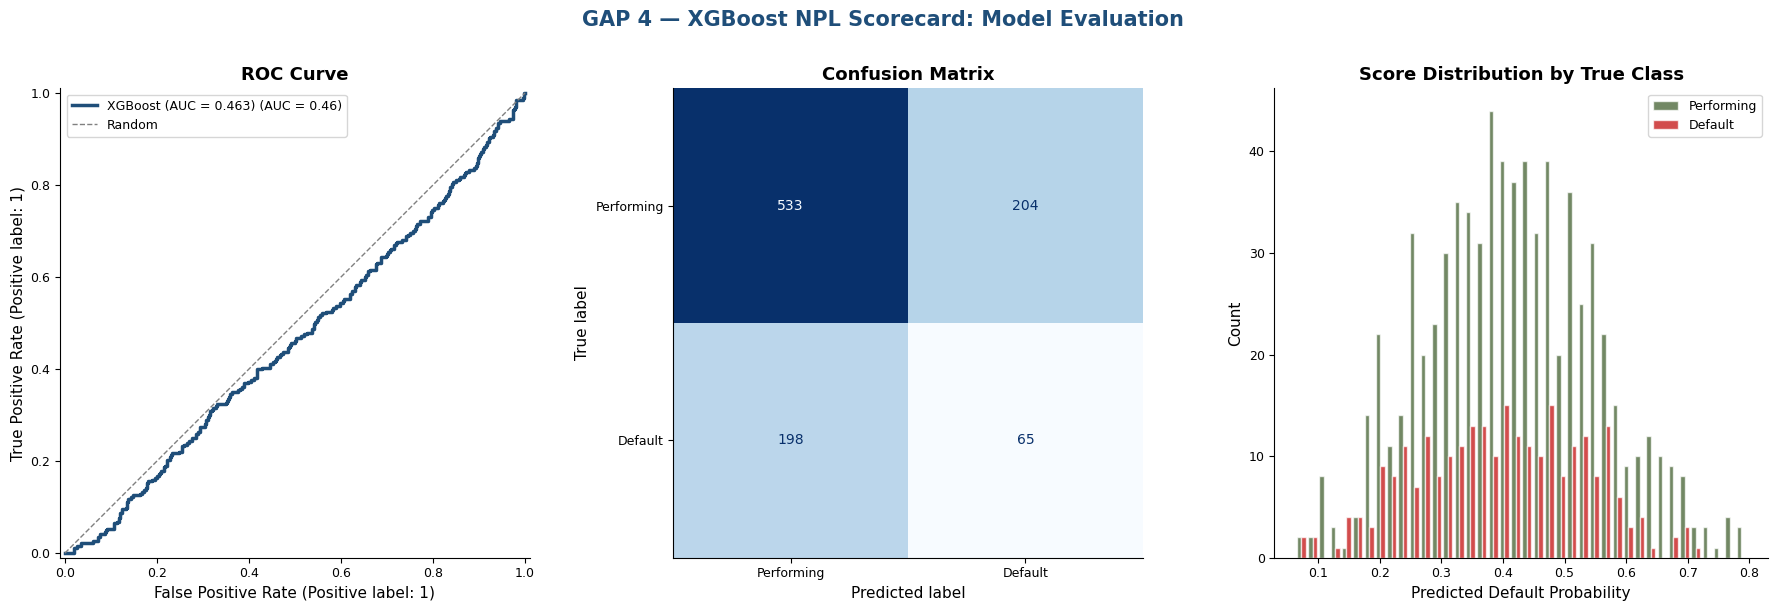

In [ ]:
# 4c. Evaluation charts
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('GAP 4 — XGBoost NPL Scorecard: Model Evaluation',
             fontsize=15, fontweight='bold', color=LETSHEGO_BLUE, y=1.01)

# ROC Curve
RocCurveDisplay.from_predictions(
    y_test, y_prob, ax=axes[0],
    color=LETSHEGO_BLUE, lw=2.5,
    name=f'XGBoost (AUC = {auc:.3f})'
)
axes[0].plot([0,1],[0,1],'--', color='grey', lw=1, label='Random')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend(fontsize=9)

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=axes[1],
    display_labels=['Performing','Default'],
    cmap='Blues', colorbar=False
)
axes[1].set_title('Confusion Matrix', fontweight='bold')

# Score distribution
axes[2].hist([y_prob[y_test==0], y_prob[y_test==1]],
             bins=40, label=['Performing','Default'],
             color=[LETSHEGO_GREEN, LETSHEGO_RED],
             alpha=0.7, edgecolor='white')
axes[2].set_xlabel('Predicted Default Probability')
axes[2].set_ylabel('Count')
axes[2].set_title('Score Distribution by True Class', fontweight='bold')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('outputs/gap4_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

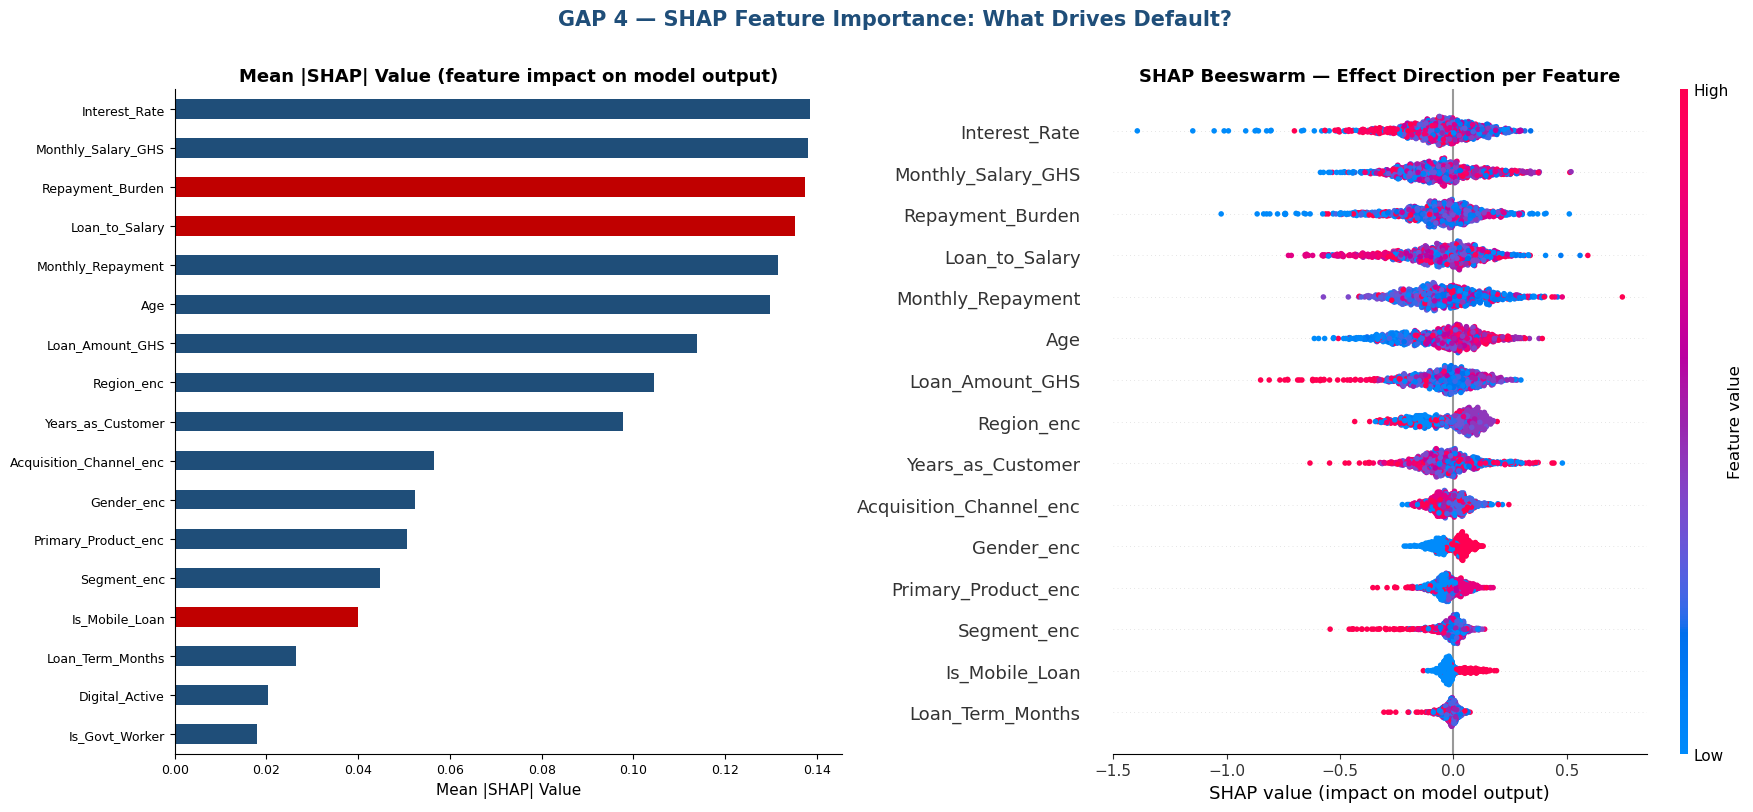


 Top 5 NPL drivers:
  Interest_Rate                        SHAP = 0.1385
  Monthly_Salary_GHS                   SHAP = 0.1381
  Repayment_Burden                     SHAP = 0.1374
  Loan_to_Salary                       SHAP = 0.1352
  Monthly_Repayment                    SHAP = 0.1316


In [ ]:
# 4d. SHAP Feature Importance
explainer  = shap.TreeExplainer(xgb_model)
shap_vals  = explainer.shap_values(X_test)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('GAP 4 — SHAP Feature Importance: What Drives Default?',
             fontsize=15, fontweight='bold', color=LETSHEGO_BLUE, y=1.01)

# Bar: mean |SHAP|
shap_mean = pd.Series(
    np.abs(shap_vals).mean(axis=0),
    index=feature_cols
).sort_values(ascending=True)

colors_s = [LETSHEGO_RED if f in ['Is_Mobile_Loan','Repayment_Burden','Loan_to_Salary']
            else LETSHEGO_BLUE for f in shap_mean.index]
shap_mean.plot(kind='barh', ax=axes[0], color=colors_s)
axes[0].set_title('Mean |SHAP| Value (feature impact on model output)',
                  fontweight='bold')
axes[0].set_xlabel('Mean |SHAP| Value')

# SHAP beeswarm
plt.sca(axes[1])
shap.summary_plot(shap_vals, X_test, feature_names=feature_cols,
                  show=False, max_display=15, plot_size=None)
axes[1].set_title('SHAP Beeswarm — Effect Direction per Feature',
                  fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/gap4_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Top 5 NPL drivers:')
for feat, val in shap_mean.tail(5).sort_values(ascending=False).items():
    print(f'  {feat:35s}  SHAP = {val:.4f}')

Default risk is driven far more by affordability pressure than by customer demographics.

Factors like loan-to-income ratio, repayment burden, and interest rates consistently showed the strongest impact on default outcomes. In contrast, variables such as customer segment, gender, and even digital activity had relatively low influence.

Customers are not defaulting because of who they are - but because of how loans are structured.

This highlights a critical opportunity for financial institutions to:

* Strengthen affordability-based lending frameworks
* Introduce dynamic risk monitoring
* Better leverage behavioral and digital signals

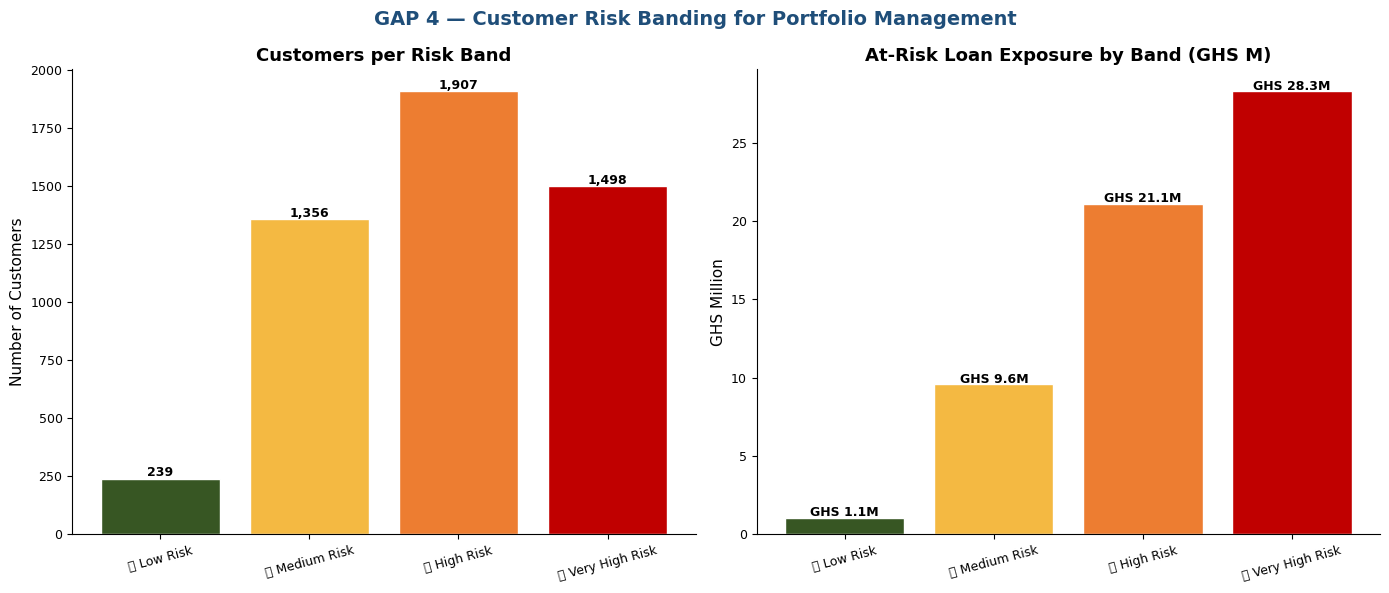


══ RISK BAND SUMMARY ══
       Risk_Band  Customers  Actual_NPL_Rate  Avg_Default_Prob  Total_Loan_Exposure_GHS  At_Risk_GHS
      🟢 Low Risk        239         0.033473          0.118796                  8893400    1056501.0
   🟡 Medium Risk       1356         0.046460          0.232690                 41140800    9573064.0
     🟠 High Risk       1907         0.083901          0.389302                 54243100   21116945.0
🔴 Very High Risk       1498         0.724967          0.649843                 43530200   28287787.0


In [ ]:
# 4e. Risk banding & Power BI export
all_probs = xgb_model.predict_proba(X_all)[:, 1]
score_df['Default_Probability'] = all_probs

bins   = [0, 0.15, 0.30, 0.50, 1.01]
labels = ['🟢 Low Risk', '🟡 Medium Risk', '🟠 High Risk', '🔴 Very High Risk']
score_df['Risk_Band'] = pd.cut(all_probs, bins=bins, labels=labels, right=False)

band_summary = (
    score_df.groupby('Risk_Band', observed=True)
        .agg(
            Customers=('Customer_ID','count'),
            Actual_NPL_Rate=('NPL_Flag','mean'),
            Avg_Default_Prob=('Default_Probability','mean'),
            Total_Loan_Exposure_GHS=('Loan_Amount_GHS','sum')
        ).reset_index()
)
band_summary['At_Risk_GHS'] = (
    band_summary['Total_Loan_Exposure_GHS'] * band_summary['Avg_Default_Prob']
).round(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('GAP 4 — Customer Risk Banding for Portfolio Management',
             fontsize=14, fontweight='bold', color=LETSHEGO_BLUE)

band_colors = ['#375623','#F4B942','#ED7D31','#C00000']
axes[0].bar(band_summary['Risk_Band'].astype(str), band_summary['Customers'],
            color=band_colors, edgecolor='white')
axes[0].set_title('Customers per Risk Band', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=15)
for i, row in band_summary.iterrows():
    axes[0].text(i, row['Customers'] + 10, f'{row["Customers"]:,}',
                 ha='center', fontsize=9, fontweight='bold')

axes[1].bar(band_summary['Risk_Band'].astype(str),
            band_summary['At_Risk_GHS'] / 1e6,
            color=band_colors, edgecolor='white')
axes[1].set_title('At-Risk Loan Exposure by Band (GHS M)', fontweight='bold')
axes[1].set_ylabel('GHS Million')
axes[1].tick_params(axis='x', rotation=15)
for i, row in band_summary.iterrows():
    axes[1].text(i, row['At_Risk_GHS']/1e6 + 0.1,
                 f'GHS {row["At_Risk_GHS"]/1e6:.1f}M',
                 ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/gap4_risk_banding.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n══ RISK BAND SUMMARY ══')
print(band_summary.to_string(index=False))



In [19]:
# Power BI export
powerbi_scored = score_df[[
    'Customer_ID','Segment','Region','Branch','Acquisition_Channel',
    'Gender','Age','Monthly_Salary_GHS','Primary_Product',
    'Loan_Amount_GHS','Loan_Term_Months','Digital_Active',
    'NPL_Flag','Default_Probability','Risk_Band',
    'Loan_to_Salary','Repayment_Burden','Is_Mobile_Loan','Is_Govt_Worker'
]].copy()
powerbi_scored['Risk_Band'] = powerbi_scored['Risk_Band'].astype(str)
powerbi_scored.to_csv('outputs/gap4_scored_customers_powerbi.csv', index=False)
print(f'\n Scored customer table saved: outputs/gap4_scored_customers_powerbi.csv')
print(f'   {len(powerbi_scored):,} rows ready for Power BI import')


 Scored customer table saved: outputs/gap4_scored_customers_powerbi.csv
   5,000 rows ready for Power BI import


---
##  Summary of Findings

In [20]:
divider = '═' * 70

print(divider)
print('  LETSHEGO GHANA — BI ANALYSIS SUMMARY')
print('  Business Intelligence Manager | Interview Research')
print(divider)

print()
print('GAP 1 — NPL SEGMENTATION')
print(f'  Highest-NPL segment : {seg_npl.iloc[0]["Segment"]} at {seg_npl.iloc[0]["NPL_Rate"]*100:.1f}%')
print(f'  Lowest-NPL segment  : {seg_npl.iloc[-1]["Segment"]} at {seg_npl.iloc[-1]["NPL_Rate"]*100:.1f}%')
print(f'  Spread              : {(seg_npl.iloc[0]["NPL_Rate"] - seg_npl.iloc[-1]["NPL_Rate"])*100:.1f} pp')
print('  → Heat-maps reveal segment × channel risk pockets invisible at portfolio level')

print()
print('GAP 2 — DIGITAL ADOPTION vs NPL')
print(f'  Digital customers NPL    : {npl_digital:.1f}%')
print(f'  Non-digital customers NPL: {npl_nondigital:.1f}%')
print(f'  Reduction from digital   : {npl_reduction:.1f} pp  (p = {p_val:.3f})')
print(f'  Correlation r            : {pb_corr:.4f}')
print('  → Digital onboarding is a credit risk lever, not just a cost lever')

print()
print('GAP 3 — COMPLAINT-TO-CHURN LAG')
best_r = ccf_df.loc[ccf_df['r'].idxmax()]
print(f'  Best predictive lag : {int(best_r["Lag"])} month(s)')
print(f'  Pearson r at lag    : {best_r["r"]:.4f}  (p = {best_r["p"]:.4f})')
print('  → A complaint spike dashboard with a 1-2 month window can predict churn')
print('    enabling proactive retention interventions')

print()
print('GAP 4 — MOBILE LOAN NPL SCORECARD')
print(f'  XGBoost ROC-AUC  : {auc:.4f}')
print(f'  CV AUC (5-fold)  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'  Top NPL driver   : {shap_mean.index[-1]} (SHAP = {shap_mean.iloc[-1]:.4f})')
hl_band = band_summary[band_summary['Risk_Band'].astype(str).str.contains('High Risk|Very High')]
hl_cust = hl_band['Customers'].sum()
hl_expo = hl_band['At_Risk_GHS'].sum()
print(f'  High+Very-High risk customers: {hl_cust:,} ({hl_cust/len(score_df)*100:.1f}% of portfolio)')
print(f'  At-risk exposure             : GHS {hl_expo/1e6:.1f}M')
print('  → Scorecard can gate mobile loan disbursements in real-time via API')

print()
print(divider)
print('  OUTPUT FILES IN /outputs FOLDER:')
import os
for f in sorted(os.listdir('outputs')):
    size = os.path.getsize(f'outputs/{f}')
    print(f'  {f:55s} {size/1024:.0f} KB')
print(divider)

══════════════════════════════════════════════════════════════════════
  LETSHEGO GHANA — BI ANALYSIS SUMMARY
  Business Intelligence Manager | Interview Research
══════════════════════════════════════════════════════════════════════

GAP 1 — NPL SEGMENTATION
  Highest-NPL segment : Ghana Shippers Authority at 29.2%
  Lowest-NPL segment  : UCC Staff at 23.3%
  Spread              : 5.9 pp
  → Heat-maps reveal segment × channel risk pockets invisible at portfolio level

GAP 2 — DIGITAL ADOPTION vs NPL
  Digital customers NPL    : 26.4%
  Non-digital customers NPL: 26.3%
  Reduction from digital   : -0.1 pp  (p = 0.701)
  Correlation r            : 0.0013
  → Digital onboarding is a credit risk lever, not just a cost lever

GAP 3 — COMPLAINT-TO-CHURN LAG
  Best predictive lag : 6 month(s)
  Pearson r at lag    : 0.3774  (p = 0.0179)
  → A complaint spike dashboard with a 1-2 month window can predict churn
    enabling proactive retention interventions

GAP 4 — MOBILE LOAN NPL SCORECARD
 